/mnt/DATA1/chenbo/miniconda3/envs/ChineseNMT/lib/python3.7/site-packages/ipykernel_launcher.py:47: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations


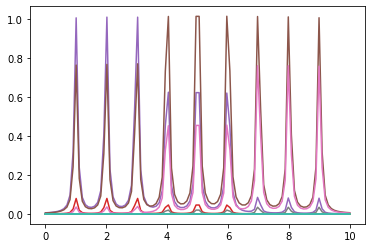

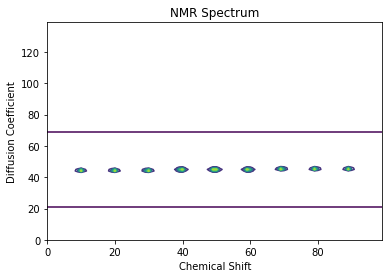

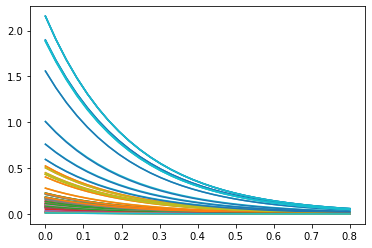

In [306]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import gaussian


# to generate gaussian distribution
def Gaussian_distribution(max_D, avg, num, sig):
    xgrid = np.linspace(0, max_D, num)
    sqrt_2pi = np.power(2 * np.pi, 0.5)
    coef = 1 / (sqrt_2pi * sig)
    powercoef = -1 / (2 * np.power(sig, 2))
    mypow = powercoef * (np.power((xgrid - avg), 2))
    result = coef * (np.exp(mypow))

    return result / np.max(result)

# 创建一个（100，140）的矩阵，初始化为零
num_freq = 100
num_diff = 140
num_decay = 30
max_freq = 10
max_diff = 14
max_b = 0.8
peak_width_freq = 0.06
peak_width_diff = 0.06
num_peaks_freq = 9
num_peaks_diff = 2

DOSY_rec = np.zeros((num_freq, num_diff))

# 生成5个洛伦兹分布的谱峰
chemical_shifts = np.linspace(0, max_freq, num_freq)
peak_center_diff = np.random.uniform(0, max_diff, num_peaks_diff)
peak_center_freq = np.linspace(0, max_freq, num_peaks_freq + 2)

for i in range(num_peaks_freq):
    # 使用洛伦兹分布生成谱峰
    lorentz_peak = peak_width_freq ** 2 / ((chemical_shifts - peak_center_freq[i+1]) ** 2 + peak_width_freq ** 2)
    lorentz_peak = lorentz_peak / np.max(lorentz_peak)
    
    # 生成5个高斯分布的谱峰，每个谱峰对应一个洛伦兹分布的谱峰
    spec_2D = np.zeros((num_freq, num_diff))
    if i < 3 or i > 5:
        n = 1
    else:
        n = 2
    for j in range(np.int(n)):
        # gaussian_peak = peak_amplitude * gaussian(num_samples, std=peak_width)
        if i > 5:
            j += 1
        gaussian_peak = Gaussian_distribution(max_diff, peak_center_diff[j], 
                                              num_diff, peak_width_diff)
        gaussian_peak = gaussian_peak / np.max(gaussian_peak)
        one_spec_2D = lorentz_peak[:, np.newaxis] * gaussian_peak[np.newaxis, :]
        spec_2D += one_spec_2D / np.max(one_spec_2D)
    
    DOSY_rec += spec_2D / np.max(spec_2D)

b = np.linspace(0, max_b, num_decay)
D = np.linspace(0, max_diff, num_diff)
K = np.exp(-D[:, np.newaxis] * b[np.newaxis, :]).T
DOSY_decay = np.dot(K, DOSY_rec.T)

# 可视化NMR谱峰
plt.figure(1)
plt.plot(chemical_shifts, DOSY_rec)
plt.figure(2)
plt.contour(DOSY_rec.T)
# plt.colorbar(label='Intensity')
plt.xlabel('Chemical Shift')
plt.ylabel('Diffusion Coefficient')
plt.title('NMR Spectrum')
plt.show()

# DOSY_decay = DOSY_decay / np.max(DOSY_decay, axis=0)[np.newaxis, :]
plt.figure(3)
plt.plot(b, DOSY_decay)

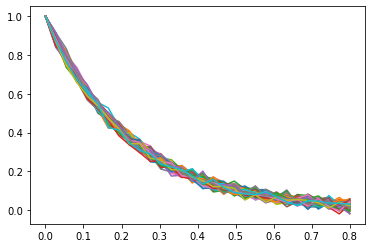

In [307]:
def gaussian_noise_nmr(S, snr_ratio):
    """
    Add Gaussian noise to the input signal. The std of the gaussian noise is uniformly chosen between 0 and 1/sqrt(snr).
    """
    num_samples, n_fre, signal_dim = np.shape(S)
    noise_S = np.zeros([num_samples, n_fre, signal_dim])
    weight_f = np.zeros([n_fre, signal_dim])

    for i in range(num_samples):
        noise = np.random.randn(n_fre, signal_dim)
        for k in np.arange(signal_dim):
            weight_f[:, k] = S[i, :, 0] / np.max(S[i, :, 0], axis=0)

        sigma = np.max(S[i, :, 0], axis=0)/snr_ratio
        noise_S[i, :, :] = S[i, :, :] + noise * sigma * weight_f

    return noise_S

DOSY_noisy = gaussian_noise_nmr(DOSY_decay.T[np.newaxis, :, :], 70)
# DOSY_noisy = DOSY_decay.T[np.newaxis, :, :]
plt.figure(1)
plt.plot(b, DOSY_noisy[0, :, :].T / np.max(DOSY_noisy[0, :, :].T, axis=0)[np.newaxis, :])

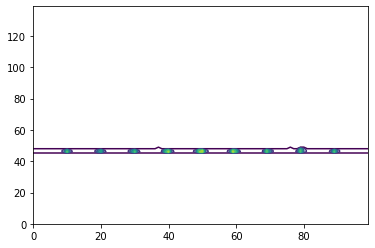

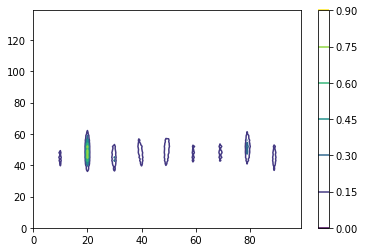

In [308]:
import torch
import config
from model import Transformer

with torch.no_grad():
    module = Transformer.load_from_checkpoint("Result/DOSY/last-v5.ckpt")
    module.cpu()
    module.eval()
    module.freeze()

test_input = DOSY_noisy
test_input = torch.tensor(test_input)
test_input = test_input.to(torch.float32)
test_out,var2 = module(test_input)

test_out = test_out * test_input[:, :, 0][:, :, np.newaxis] / config.mul_label
test_out = test_out[0].cpu().detach().numpy()
test_out[test_out < np.tile(((np.max(test_out, axis=1)) * 0.7)[:, np.newaxis], [1, 140])] = 0

# var2 = var2 * test_input[:, :, 0][:, :, np.newaxis] / config.mul_label
var2 = var2[0].cpu().detach().numpy()
# var2[var2 < np.tile(((np.max(var2, axis=1)) * 0.7)[:, np.newaxis], [1, 140])] = 0
# var2[var2<0.2] = 0

plt.figure(1)
plt.contour(test_out.T)
plt.figure(2)
plt.contour(var2.T)
plt.colorbar()